# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import matplotlib.ticker as ticker # Custom formatter: Format y-axis labels as Millions/Thousands

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# ============================================
# Custom Formatter Functions
# ============================================

# Format numbers in thousands (e.g., 10,000 → 10K)
def thousands_formatter(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.0f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

# Format dollars in millions/thousands
def dollars_formatter(x, pos):
    if x >= 1e6:
        return f'${x/1e6:.1f}M'
    elif x >= 1e3:
        return f'${x/1e3:.0f}K'
    else:
        return f'${x:.0f}'

# Register the formatters
thousands_fmt = ticker.FuncFormatter(thousands_formatter)
dollars_fmt = ticker.FuncFormatter(dollars_formatter)


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

**OBJECTIVE:**
To develop a model that estimates the tax-assessed value of residential properties based on their physical characteristics, location, and other property attributes.


**1.2:**  How will your solution be used?

**Solution Usage**

- For Home buyers: determine fair market value
- For Professionals: make investment decisions
- For Businesses: Predict market trend


**1.3:**  How should success (or failure) be measured?

**The metrics of success**

- MAE score: As low as possible
- RMSE score: Lower is better 
- R2 score: Help to explain variances

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
# ============================================
# PART 2: Initial Exploration
# ============================================

print("ZILLOW DATASET - INITIAL EXPLORATION")
print("*" * 60)

# 2.A.1. Dataset shape
print(f"\n1. Dataset shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# 2.A.2. Target variable summary
print(f"\n2. Target variable: taxvaluedollarcnt")
print("~" * 60)
print(f"   Mean: ${df['taxvaluedollarcnt'].mean():,.2f}")
print(f"   Median: ${df['taxvaluedollarcnt'].median():,.2f}")
print(f"   Min: ${df['taxvaluedollarcnt'].min():,.2f}")
print(f"   Max: ${df['taxvaluedollarcnt'].max():,.2f}")
print(f"   Std: ${df['taxvaluedollarcnt'].std():,.2f}")
print(f"   Missing values: {df['taxvaluedollarcnt'].isnull().sum():,}")

# 2.A.3. Data types summary
print(f"\n3. Data types summary")
print("~" * 60)
print("   " + df.dtypes.value_counts().to_string().replace("\n", "\n   "))

# 2.A.4. Missing values analysis
print(f"\n4. Missing values summary")
print("~" * 60)

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print("\nColumns with missing values (>10% missing):")
print(missing_df[missing_df['Missing %'] > 10])

print("\nColumns with no missing values: " + str(df.columns[df.isnull().sum() == 0].tolist()))

# 2.A.5. View first 5 rows
print(f"\n5. First 5 rows of the dataset:")
print("~" * 60)
print(df.head())

# 2.A.6. Column info summary
print(f"\n6. Column info summary:")
print("~" * 60)
print(df.info())

# 2.A.7. Unique value counts
print(f"\n7. Unique value counts:")
print("~" * 60)
nunique_df = pd.DataFrame({
    'Unique Values': df.nunique()
}).sort_values('Unique Values', ascending=False)
print(nunique_df)

ZILLOW DATASET - INITIAL EXPLORATION
************************************************************

1. Dataset shape: (77613, 55)
   Rows: 77,613
   Columns: 55

2. Target variable: taxvaluedollarcnt
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Mean: $490,150.59
   Median: $358,878.50
   Min: $1,000.00
   Max: $49,061,236.00
   Std: $653,797.86
   Missing values: 35

3. Data types summary
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   float64    49
   object      5
   int64       1

4. Missing values summary
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Columns with missing values (>10% missing):
                          Missing Count  Missing %
buildingclasstypeid               77598  99.980673
finishedsquarefeet13              77571  99.945885
basementsqft                      77563  99.935578
storytypeid                       77563  99.935578
yardbuildingsqft26                77543  99.909809
fireplaceflag                     77441

#### **2.A Discussion:** 

Answer the following questions. You may wish to examine Appendix 3 before starting. 

**2.A.1:**  Which features are categorical?

Based on the feature descriptions in Appendix 1, and output from part 2.A, here are 22 categorical features:

- airconditioningtypeid: Type of AC
- architecturalstyletypeid: Architectural style
- buildingclasstypeid: Building framing type
- buildingqualitytypeid: Quality rating
- decktypeid: Deck type
- fips: County code
- hashottuborspa: Has hot tub/spa
- heatingorsystemtypeid: Heating type
- pooltypeid10: Spa/hot tub type
- pooltypeid2: Pool with spa type
- pooltypeid7: Pool without spa
- propertycountylandusecode: County land use
- propertylandusetypeid: Land use type
- propertyzoningdesc: Zoning description
- regionidcity: City
- regionidcounty: County
- regionidneighborhood: Neighborhood
- regionidzip: ZIP code
- storytypeid: Story type
- typeconstructiontypeid: Construction type
- fireplaceflag: Has fireplace or not
- taxdelinquencyflag: Tax delinquent



**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Based on the feature descriptions in Appendix 1, and output from part 2.A, here are 12 useless features for business purpose, and the reasons. These serve no predictive value for our model:

- parcelid: unique identifier
- rawcensustractandblock: track and block unique identifier
- censustractandblock: part of the U.S. Census geographic hierarchy
- architecturalstyletypeid:	99.7% missing
- buildingclasstypeid: 99.98% missing
- decktypeid: identifier for the type of deck. Either has value of "66" or missing
- pooltypeid10: Identifier for spa or hot tub . 99% missing
- pooltypeid2: Identifier for pool with spa or hot tub. All missing
- pooltypeid7: Identifier for pool without hot tub or spa. All missing
- storytypeid: Identifier for the type of stories. All missing
- typeconstructiontypeid: 99.7% missing
- assessmentyear: Year the property was assessed. All has the same year of 2016

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Based on 2.A analysis #4 of missing values summary above, these 20 features each has > 90% of missing data (Note: some already listed above in 2.A.2)

- buildingclasstypeid: 99.98%
- finishedsquarefeet13: 99.95%
- basementsqft: 99.94%
- storytypeid: 99.94%
- yardbuildingsqft26: 99.91%
- fireplaceflag: 99.78%
- architecturalstyletypeid: 99.73%
- typeconstructiontypeid: 99.71%
- finishedsquarefeet6: 99.50%
- pooltypeid10: 99.40%
- decktypeid: 99.21%
- poolsizesum: 98.88%
- pooltypeid2: 98.62%
- hashottuborspa: 98.02%
- yardbuildingsqft17: 96.92%
- taxdelinquencyyear: 96.26%
- taxdelinquencyflag: 96.26%
- finishedsquarefeet15: 96.10%
- finishedsquarefeet50: 92.22%
- finishedfloor1squarefeet: 92.22%

For example: 
`fireplaceflag` has only 172 "TRUE" value. It's missing 77,441 or 99.78% values (either no Fireplace or not recorded). This is far too few to learn any meaningful pattern.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Based on 2.A analysis #7 of unique value summary above, these 10 features each has only 1 unique count.

- decktypeid
- hashottuborspa
- poolcnt
- pooltypeid10
- pooltypeid2
- pooltypeid7
- storytypeid
- fireplaceflag
- assessmentyear
- taxdelinquencyflag

For example: 
`assessmentyear` has only 2016 as the year of the assessment. This serves no purpose for the analysis or predictive

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features): 
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

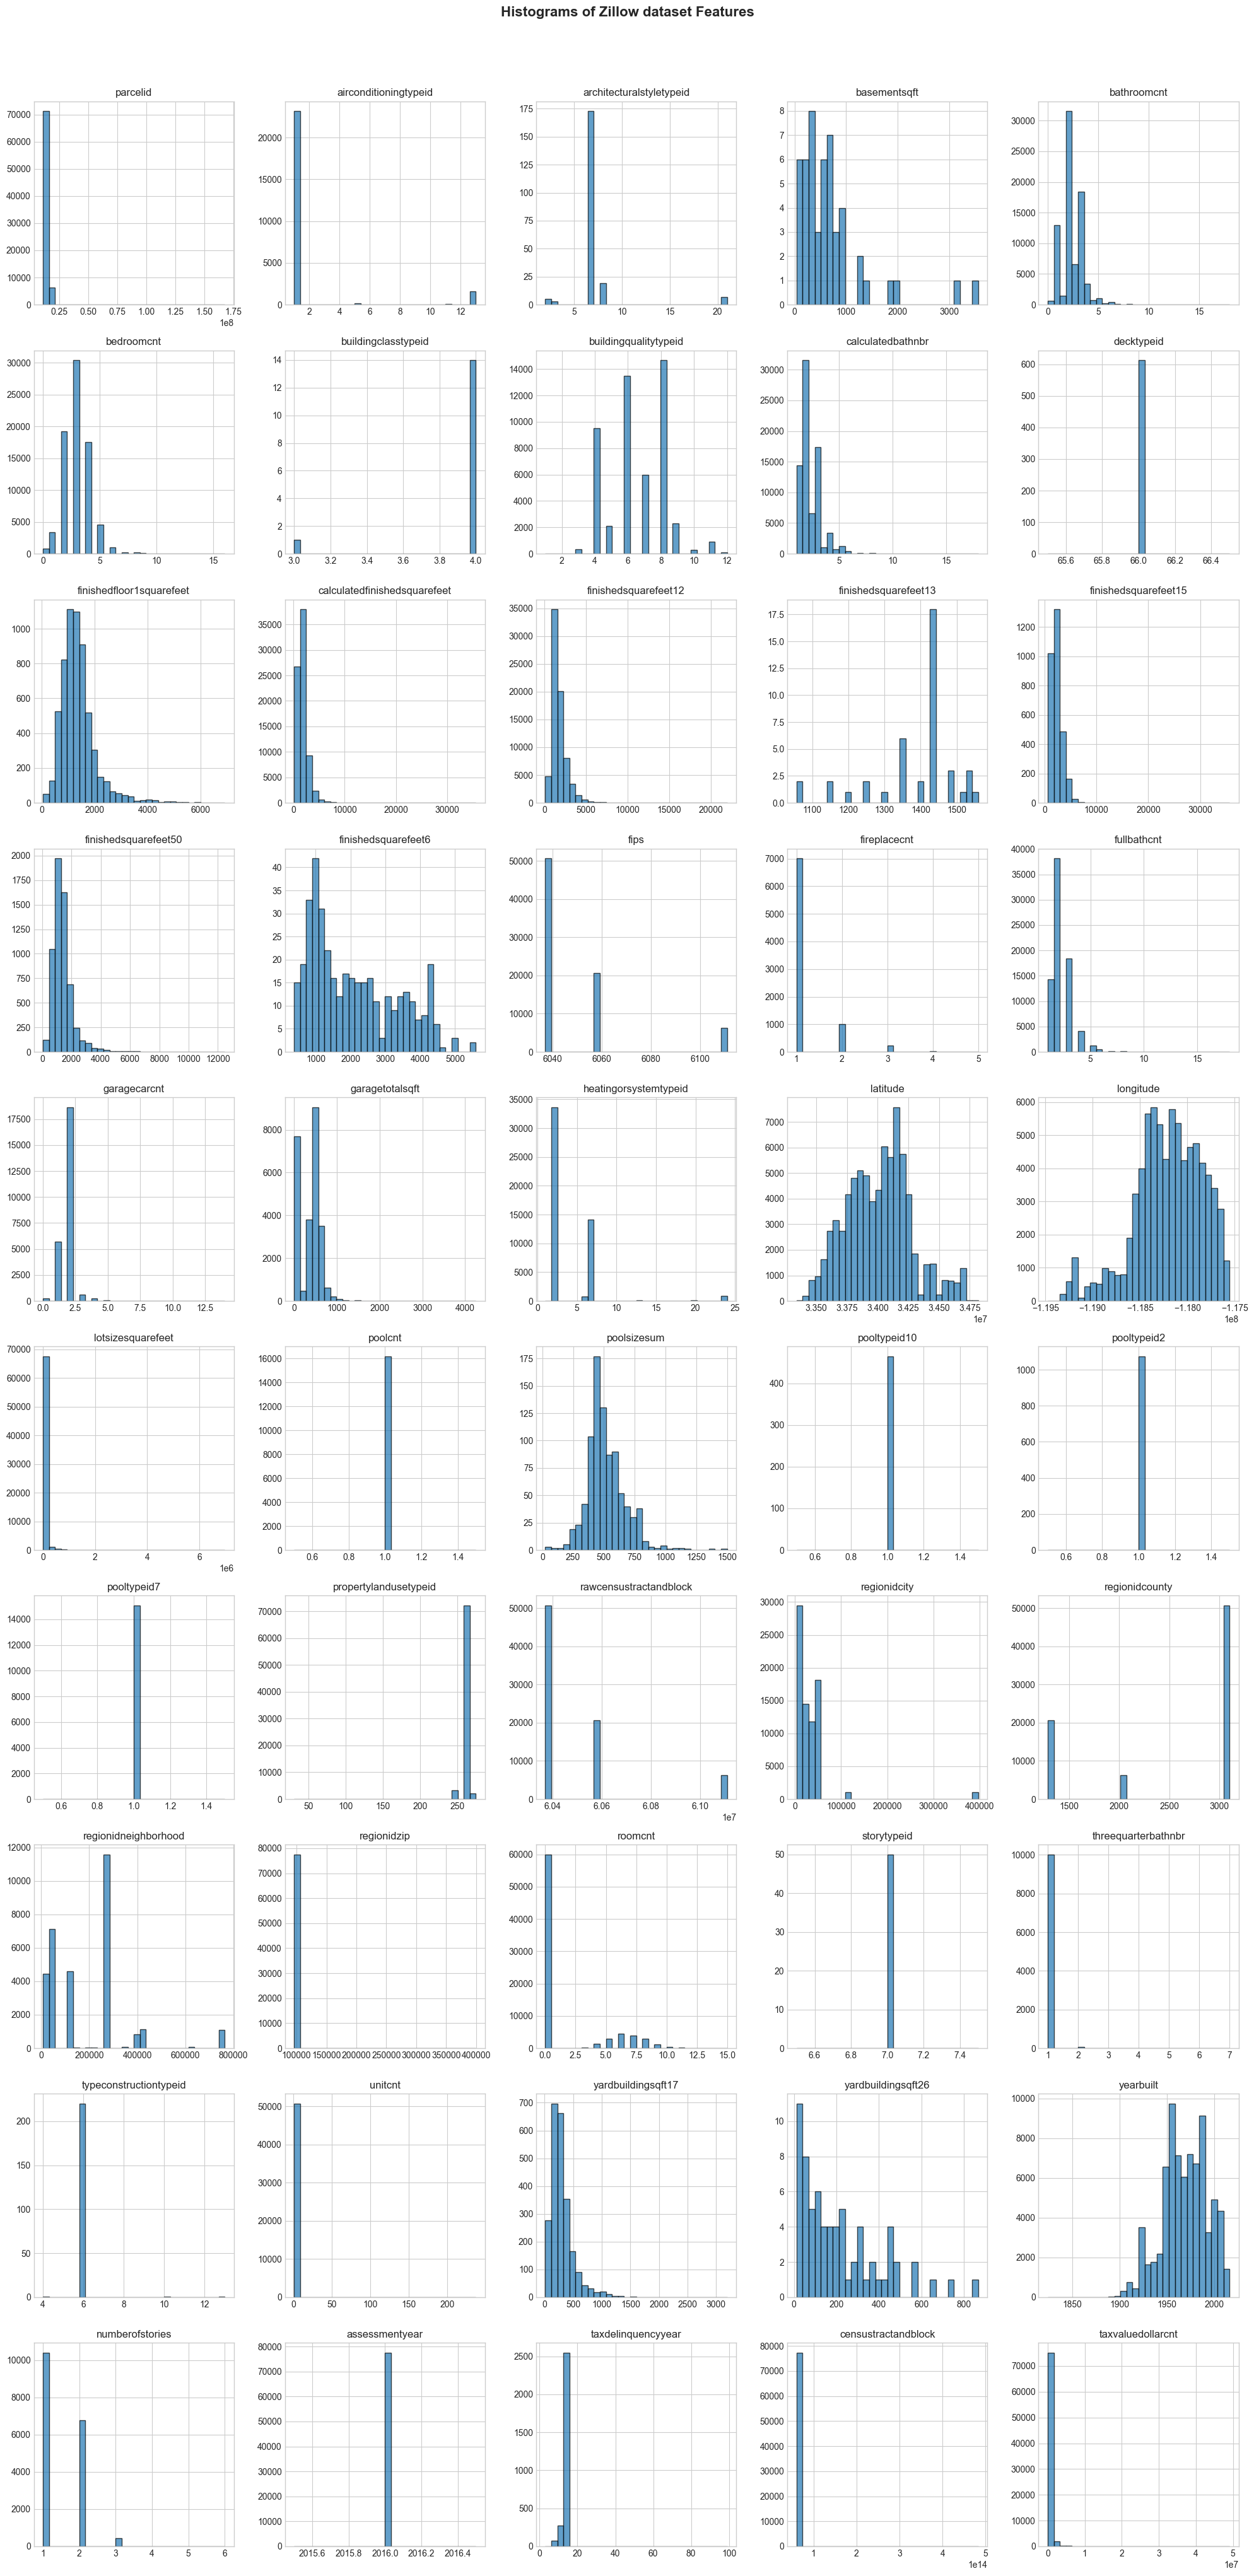

In [5]:
# 2.B.1: Histograms of all features
# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Generate histograms for all features
df.hist(figsize=(20, 40), bins=30, layout=(-1, 5), edgecolor='black', alpha=0.7)

plt.suptitle('Histograms of Zillow dataset Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

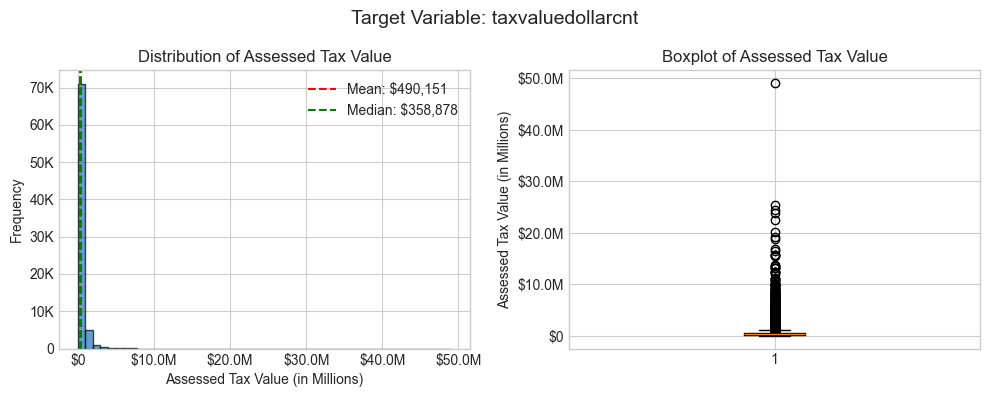

In [6]:
# 2.B.2: Generate individual visualizations for the target variable

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['taxvaluedollarcnt'].mean(), color='red', linestyle='--', label=f"Mean: ${df['taxvaluedollarcnt'].mean():,.0f}")
axes[0].axvline(df['taxvaluedollarcnt'].median(), color='green', linestyle='--', label=f"Median: ${df['taxvaluedollarcnt'].median():,.0f}")
axes[0].set_xlabel('Assessed Tax Value (in Millions)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Assessed Tax Value')
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].xaxis.set_major_formatter(dollars_fmt)
axes[0].yaxis.set_major_formatter(thousands_fmt)
axes[0].legend()

# Boxplot to find outliers
axes[1].boxplot(df['taxvaluedollarcnt'].dropna())
axes[1].set_ylabel('Assessed Tax Value (in Millions)')
axes[1].set_title('Boxplot of Assessed Tax Value')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].yaxis.set_major_formatter(dollars_fmt)

plt.suptitle('Target Variable: taxvaluedollarcnt', fontsize=14)
plt.tight_layout()
plt.show()

Total Finished Living Area Statistics
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mean:   1,785 sq ft
Median: 1,542 sq ft
Min:    128 sq ft
Max:    35,640 sq ft
Std:    954 sq ft
Missing: 235 (0.30%)


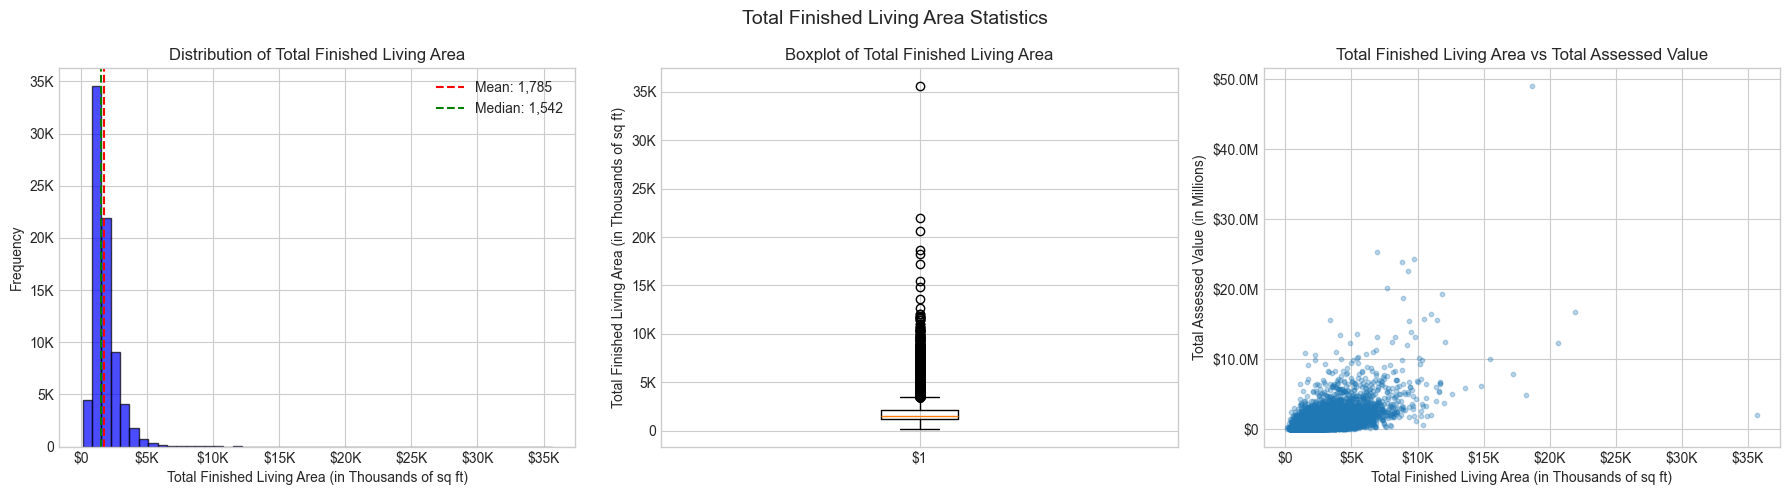

In [7]:
# 2.B.3: Three Additional Informative Features

# We'll look at the 3 features that we think will be most informative for predicting the target variable: 
# 2.B.3.1. Total finished living area square footage (calculatedfinishedsquarefeet). How big is the house?
# 2.B.3.2. Year the property was built (yearbuilt). How old is the house?
# 2.B.3.3. Building quality rating (buildingqualitytypeid). How well was the house built? (1-12 scale, 12 = best quality)

# 2.B.3.1: calculatedfinishedsquarefeet (Total Finished Living Area)

# Summary statistics
print("Total Finished Living Area Statistics")
print("~" * 60)
print(f"Mean:   {df['calculatedfinishedsquarefeet'].mean():,.0f} sq ft")
print(f"Median: {df['calculatedfinishedsquarefeet'].median():,.0f} sq ft")
print(f"Min:    {df['calculatedfinishedsquarefeet'].min():,.0f} sq ft")
print(f"Max:    {df['calculatedfinishedsquarefeet'].max():,.0f} sq ft")
print(f"Std:    {df['calculatedfinishedsquarefeet'].std():,.0f} sq ft")
print(f"Missing: {df['calculatedfinishedsquarefeet'].isnull().sum():,} ({df['calculatedfinishedsquarefeet'].isnull().mean()*100:.2f}%)")

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].axvline(df['calculatedfinishedsquarefeet'].mean(), color='red', linestyle='--', label=f"Mean: {df['calculatedfinishedsquarefeet'].mean():,.0f}")
axes[0].axvline(df['calculatedfinishedsquarefeet'].median(), color='green', linestyle='--', label=f"Median: {df['calculatedfinishedsquarefeet'].median():,.0f}")
axes[0].set_xlabel('Total Finished Living Area (in Thousands of sq ft)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Finished Living Area')
axes[0].xaxis.set_major_formatter(dollars_fmt)
axes[0].yaxis.set_major_formatter(thousands_fmt)
axes[0].legend()

# Boxplot
axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=True)
axes[1].set_ylabel('Total Finished Living Area (in Thousands of sq ft)')
axes[1].set_title('Boxplot of Total Finished Living Area')
axes[1].xaxis.set_major_formatter(dollars_fmt)
axes[1].yaxis.set_major_formatter(thousands_fmt)

# Scatter plot with target
axes[2].scatter(df['calculatedfinishedsquarefeet'], df['taxvaluedollarcnt'], alpha=0.3, s=10)
axes[2].set_xlabel('Total Finished Living Area (in Thousands of sq ft)')
axes[2].set_ylabel('Total Assessed Value (in Millions)')
axes[2].set_title('Total Finished Living Area vs Total Assessed Value')
axes[2].xaxis.set_major_formatter(dollars_fmt)
axes[2].yaxis.set_major_formatter(dollars_fmt)

plt.suptitle('Total Finished Living Area Statistics', fontsize=14)
plt.tight_layout()
plt.show()

Year the property was built Statistics
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mean:   1969
Median: 1970
Min:    1824
Max:    2016
Std:    24
Missing: 304 (0.39%)


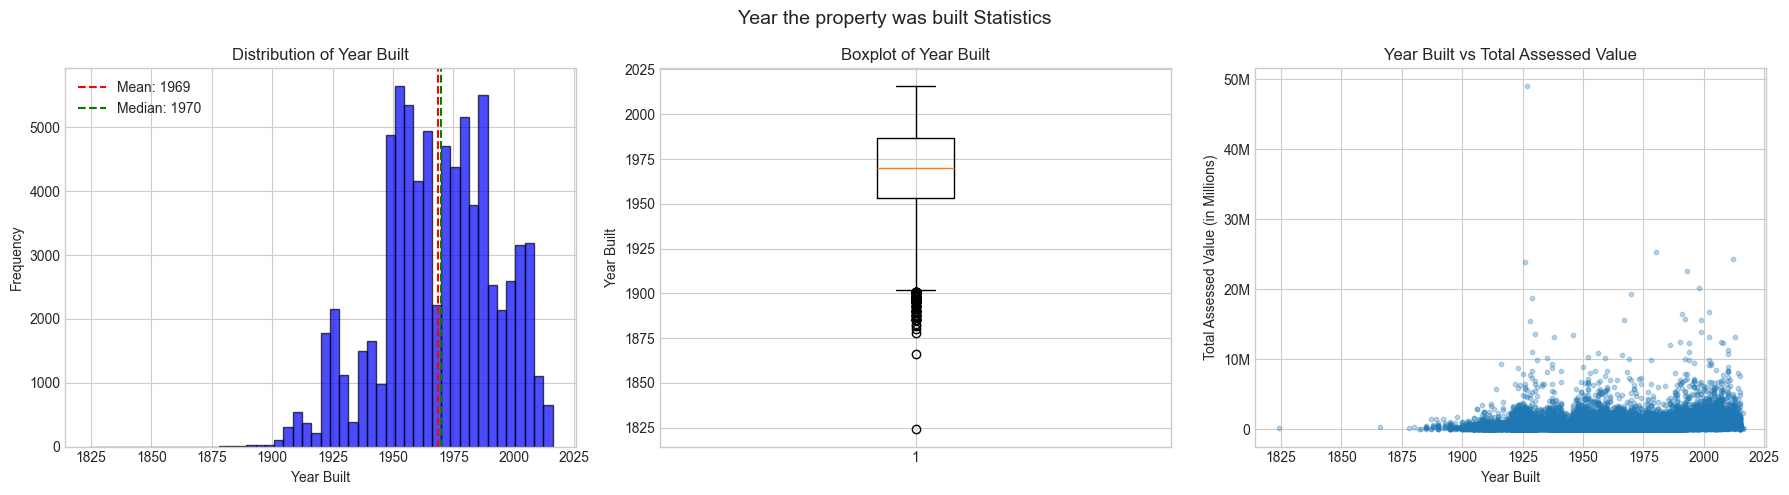

In [8]:
# 2.B.3.2: yearbuilt (Year Built)

# Summary statistics
print("Year the property was built Statistics")
print("~" * 60)
print(f"Mean:   {df['yearbuilt'].mean():.0f}")
print(f"Median: {df['yearbuilt'].median():.0f}")
print(f"Min:    {df['yearbuilt'].min():.0f}")
print(f"Max:    {df['yearbuilt'].max():.0f}")
print(f"Std:    {df['yearbuilt'].std():.0f}")
print(f"Missing: {df['yearbuilt'].isnull().sum():,} ({df['yearbuilt'].isnull().mean()*100:.2f}%)")

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['yearbuilt'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].axvline(df['yearbuilt'].mean(), color='red', linestyle='--', label=f"Mean: {df['yearbuilt'].mean():.0f}")
axes[0].axvline(df['yearbuilt'].median(), color='green', linestyle='--', label=f"Median: {df['yearbuilt'].median():.0f}")
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Year Built')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['yearbuilt'].dropna(), vert=True)
axes[1].set_ylabel('Year Built')
axes[1].set_title('Boxplot of Year Built')

# Scatter plot with target
axes[2].scatter(df['yearbuilt'], df['taxvaluedollarcnt'], alpha=0.3, s=10)
axes[2].set_xlabel('Year Built')
axes[2].set_ylabel('Total Assessed Value (in Millions)')
axes[2].set_title('Year Built vs Total Assessed Value')
axes[2].ticklabel_format(style='plain', axis='y')
axes[2].yaxis.set_major_formatter(thousands_fmt)

plt.suptitle('Year the property was built Statistics', fontsize=14)
plt.tight_layout()
plt.show()

The Quality of The Building Statistics
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Unique values: 12
Missing: 27,804 (35.82%)

Quality Rating Distribution:
buildingqualitytypeid
1.0        26
2.0         9
3.0       335
4.0      9508
5.0      2099
6.0     13501
7.0      5981
8.0     14685
9.0      2303
10.0      313
11.0      933
12.0      116
Name: count, dtype: int64


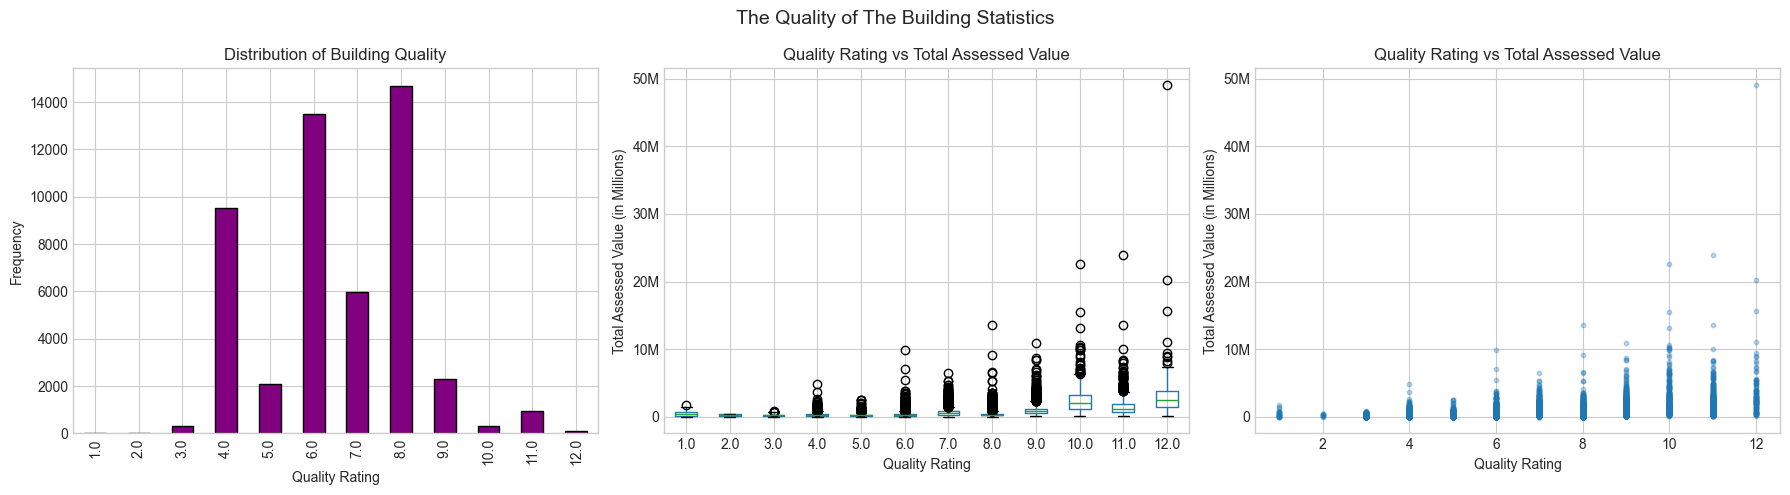

In [9]:
# 2.B.3.3: buildingqualitytypeid (Building Quality)

# Summary statistics
print("The Quality of The Building Statistics")
print("~" * 60)
print(f"Unique values: {df['buildingqualitytypeid'].nunique()}")
print(f"Missing: {df['buildingqualitytypeid'].isnull().sum():,} ({df['buildingqualitytypeid'].isnull().mean()*100:.2f}%)")

# Value counts for categorical analysis
quality_counts = df['buildingqualitytypeid'].value_counts().sort_index()
print("\nQuality Rating Distribution:")
print(quality_counts)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot of quality ratings
quality_counts.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_xlabel('Quality Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Building Quality')
axes[0].ticklabel_format(style='plain', axis='y')

# Boxplot of quality vs tax value
quality_vs_value = df.dropna(subset=['buildingqualitytypeid', 'taxvaluedollarcnt'])
quality_vs_value.boxplot(column='taxvaluedollarcnt', by='buildingqualitytypeid', ax=axes[1])
axes[1].set_xlabel('Quality Rating')
axes[1].set_ylabel('Total Assessed Value (in Millions)')
axes[1].set_title('Quality Rating vs Total Assessed Value')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].yaxis.set_major_formatter(thousands_fmt)

# Scatter plot quality vs tax value
axes[2].scatter(df['buildingqualitytypeid'], df['taxvaluedollarcnt'], alpha=0.3, s=10)
axes[2].set_xlabel('Quality Rating')
axes[2].set_ylabel('Total Assessed Value (in Millions)')
axes[2].set_title('Quality Rating vs Total Assessed Value')
axes[2].ticklabel_format(style='plain', axis='y')
axes[2].yaxis.set_major_formatter(thousands_fmt)

plt.suptitle('The Quality of The Building Statistics', fontsize=14)
plt.tight_layout()
plt.show()

#### **2.B Discussion:** 

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

#### **1. Total assessed value of the property (land plus structure)**

**The Target Variable: taxvaluedollarcnt variable - From 2.A.2**
- Mean: $490,150.59
- Median: $358,878.50
- Min: $1,000.00
- Max: $49,061,236.00
- Std: $653,797.86
- Missing values: 35

**What I Learned**

- The target variable is highly right-skewed with a long tail toward high values.

    - The Mean ($490,150) is about $130K more than the Median ($358,878)

    - There are extreme outliers: max value is ~$49M vs Median ~$359K

    - There are some higher-end or luxury properties ranging $10M - $25M

- Standard deviation ($653,798) is larger than the mean, indicating high variability

- Most properties in this region are in the $150K–$400K range

- There is a significant luxury properties with values > $1M

- The extremely high values (>$10M-$25M) are rare but present

- Need to investigate the Outlier and decide whether to cap extreme values or keep them

#### **2. The Total finished living area square footage**

**Feature: calculatedfinishedsquarefeet**
- Mean: 1,784.94 sq ft
- Median: 1,542.00 sq ft
- Min: 128.00 sq ft
- Max: 35,640.00 sq ft
- Std: 954.25 sq ft
- Missing values: 235

**What I Learned**

- Most homes are between 1,000-2,500 sq ft

- The mean and median values are closer in this analysis, but still highly right skew

- There is a positive correlation with total assesses taxable value (larger homes = higher value)

- Some larger home (10,000 - 23,000 sq ft) are present

- There are extreme outliers (as small as 128 sq ft to as high as 35,000 sq ft)

- Missing values: only 235 (0.30%) - very complete!

#### **3. Year the property was built**

**Feature: yearbuilt (Year Constructed)**
- Mean: 1,968.61
- Median: 1,970.00
- Min: 1,824.00
- Max: 2,016.00
- Std: 23.79
- Missing values: 304
   
**What I Learned**

- Most homes were built between 1950-2010

- There are a few homes built before 1920

- Some reported property dated back to 1825 (extreme outliers)

- Some older home (built 1925s) have ~50Million assessed values (probably wrong)

- Newer homes have have higher taxable values

- Missing values: only 304 (0.39%) - very complete!

#### **4. The quality of the building (higher values often indicate better quality)**

**Feature: buildingqualitytypeid (Building Quality Rating)**
- Unique values: 12
- Min: 1.00
- Max: 12.00
- Mean: 6.53
- Median: 6.00
- Missing values: 27,804
- Missing %: 35.82%
   
**What I Learned**

- Need to learn more about the rating. Usually we have 1-10, but this has 11 and 12 as well

- Higher quality ratings (8-10) tend to have higher tax values

- Lower quality ratings (1-3) have lower tax values

- Quality is a strong predictor of property value

- Missing values: 27,804 (35.8%) - need imputation. I realized this feature has so many missing values. Will need to decide whether or not to keep this features in our analysis.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [10]:
# 3.A: Columns to drop

# Based on Part 2 analysis, these 24 features don't add any values to the analysis

columns_to_drop = [
    # Identifiers (3)
    'parcelid',
    'rawcensustractandblock',
    'censustractandblock',  
      
    # >90% Missing (20)
    'buildingclasstypeid',
    'finishedsquarefeet13',
    'basementsqft',
    'storytypeid',
    'yardbuildingsqft26',
    'fireplaceflag',
    'architecturalstyletypeid',
    'typeconstructiontypeid',
    'finishedsquarefeet6',
    'pooltypeid10',
    'decktypeid',
    'poolsizesum',
    'pooltypeid2',
    'hashottuborspa',
    'yardbuildingsqft17',
    'taxdelinquencyyear',
    'taxdelinquencyflag',
    'finishedsquarefeet15',
    'finishedsquarefeet50',
    'finishedfloor1squarefeet',
    
    # Constant (1)
    'assessmentyear',
]

# 1st initial drop of the columns from the DataFrame
df_clean = df.drop(columns=columns_to_drop)

# We also use the provided code from HW 4 to show the null counts and percentages for each feature in the dataset.
def show_null_counts_features(df):
    # Count the nulls and calculate the %
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)
    
    # Determine if the column is numeric or non-numeric
    feature_types = df.dtypes.apply(lambda x: 'Numeric' if np.issubdtype(x, np.number) else 'Categorical')
    
    # Filter out the columns with missing values and sort them in descending order
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values, 
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)
    
    print(f'The dataset contains {len(df)} samples.\n')

    if (len(missing_data) == 0):
        print("There are no null values in the dataset!")
    else:
        # Print null value stats
        print('Feature Name                    # Nulls  Null %   Type')
        print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~  ~~~~~~~  ~~~~~~  ~~~~~~~')
        for index, row in missing_data.iterrows():
            print(f"{row['Feature']:<30} {row['# Null Values']:>8} {row['Null %']:6.2f}%  {row['Type']}")

show_null_counts_features(df_clean)

The dataset contains 77613 samples.

Feature Name                    # Nulls  Null %   Type
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~  ~~~~~~~  ~~~~~~  ~~~~~~~
fireplacecnt                      69324  89.32%  Numeric
threequarterbathnbr               67507  86.98%  Numeric
pooltypeid7                       62534  80.57%  Numeric
poolcnt                           61439  79.16%  Numeric
numberofstories                   60014  77.32%  Numeric
airconditioningtypeid             52606  67.78%  Numeric
garagecarcnt                      52093  67.12%  Numeric
garagetotalsqft                   52093  67.12%  Numeric
regionidneighborhood              46639  60.09%  Numeric
heatingorsystemtypeid             28042  36.13%  Numeric
buildingqualitytypeid             27804  35.82%  Numeric
propertyzoningdesc                27137  34.96%  Categorical
unitcnt                           26910  34.67%  Numeric
lotsizesquarefeet                  8292  10.68%  Numeric
finishedsquarefeet12               3690   4.75%  

#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

####  **Features Removed and Justification**

#### 1. Identifiers (3 features)

| Feature | Reason for Removal | Business Justification |
|---------|-------------------|----------------------|
| `parcelid` | Unique identifier | This is a unique ID for each property parcel. It has no relationship with property value. |
| `rawcensustractandblock` | Tract/block unique identifier | This identifies specific census tracts and blocks, which has no relationship with property value. |
| `censustractandblock` | Part of the U.S. Census geographic hierarchy identifier | This is a geographic identifier doesn't help predict property value. |

**Decision basis:** These 3 are **identifiers**, not property characteristics. They don't provide predictive value.

---

#### 2. Features with >90% Missing Values (20 features)

| Feature | Missing % | Reason for Removal |
|---------|-----------|-------------------|
| `buildingclasstypeid` | 99.98% | Only 15 properties have data. |
| `finishedsquarefeet13` | 99.95% | Living are. Only 42 properties recorded |
| `basementsqft` | 99.94% | Basements are rare in this region. Only 50 properties have basements |
| `storytypeid` | 99.94% | Almost all missing. Insufficient data |
| `yardbuildingsqft26` | 99.91% | Only 70 properties have this yard building |
| `fireplaceflag` | 99.78% | Redundant with `fireplacecnt` (which also has high missing) |
| `architecturalstyletypeid` | 99.73% | Architectural style. Only 207 properties recorded |
| `typeconstructiontypeid` | 99.71% | Construction type. Only 223 properties recorded |
| `finishedsquarefeet6` | 99.50% | Base area. Only 386 properties recorded |
| `pooltypeid10` | 99.40% | Identifier for spa or hot tub. Redundant with `poolcnt` |
| `decktypeid` | 99.21% | Identifier for the type of deck. All values are "66" or missing |
| `poolsizesum` | 98.88% | Total square footage of all pools.  |
| `pooltypeid2` | 98.62% | Identifier for pool with spa or hot tub |
| `hashottuborspa` | 98.02% | Hot tub/spar indicator. Only 2% have data |
| `yardbuildingsqft17` | 96.92% | Square footage of the 17th yard building. Only 3% have data |
| `taxdelinquencyyear` | 96.26% | Tax delinquency year. Only 3.7% have data |
| `taxdelinquencyflag` | 96.26% | Tax delinquency flag. Only 3.7% have data |
| `finishedsquarefeet15` | 96.10% | Total area. Too few meaningful data to consider |
| `finishedsquarefeet50` | 92.22% | Upper floor area. Too few meaningful data to consider |
| `finishedfloor1squarefeet` | 92.22% | First floor area. Too few meaningful data to consider |

**Decision basis:** With > 90% missing, these features have **too few data** to be reliable predictors. Including them would introduce noise rather than meaningful data.

---

#### 3. Constant Feature (1 feature)

| Feature | Reason for Removal | Business Justification |
|---------|-------------------|----------------------|
| `assessmentyear` | All values are 2016 | No variation over time means no predictive power |

**Decision basis:** A feature with **no variation** provides **no information**.

---

#### **Why Features with Missing Data Were Kept**

The following features were **kept despite having missing data** because they have **business meaning** and **reasonable/enough data** for analysis:

| Feature | Missing % | Why Kept |
|---------|-----------|----------|
| `poolcnt` | 79.16% | Pools add significant property value. To be converted to binary |
| `airconditioningtypeid` | 67.78% | AC is important for property value |
| `garagecarcnt` | 67.12% | Garage capacity is a key value driver |
| `garagetotalsqft` | 67.12% | Garage size is also a key value driver |
| `regionidneighborhood` | 60.09% | Neighborhood is a strong predictor of value |
| `heatingorsystemtypeid` | 36.13% | Heating type is importance when buying a house |
| `buildingqualitytypeid` | 35.82% | Building Quality is a strong predictor of value |
| `propertyzoningdesc` | 34.96% | Zoning affects property use and value |
| `unitcnt` | 34.67% | Number of units affects property value |

**Decision basis:** These features have **business meaning** and **enough data** (20-65% non-missing) to be useful after imputation. The decision was based on **feature meaning**, not just missing percentage.

---

#### **Features with High Missing But may be Kept/removed**

From the output, these features have high missing data, may still be useful, but probaby be dropped:

| Feature | Missing % | Consideration |
|---------|-----------|---------------|
| `fireplacecnt` | 89.32% | Could be useful but likely too few recorded data  |
| `threequarterbathnbr` | 86.98% | Could be useful but could already be counted in total bathroom count |
| `pooltypeid7` | 80.57% | Identify pool without spa. Could be useful but we could use pooltypeid2 (with spa) |
| `numberofstories` | 77.32% | Would be useful but likely to drop since too many missing data |

These will be discussed further in **Part 3.B**

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [11]:
# After further analysis, we decided to drop the following 4 features due to high missing values and low correlation with the target variable:
# - Feature 1: fireplacecnt. While fireplaces can add value, the data is too little to reliably use
# - Feature 2: threequarterbathnbr. Already captured in bathroomcnt and calculatedbathnbr. This feature adds no new information.
# - Feature 3: pooltypeid7. Already captured by poolcnt
# - Feature 4: numberofstories. The missing data is too extensive to impute reliably.

additional_drop = [
    'fireplacecnt',           # 89.32% missing. Only 8,289 properties (10.7%) has data
    'threequarterbathnbr',    # 86.98% missing. Only 10,106 properties (13.0%) has data
    'pooltypeid7',            # 80.57% missing. Only has data for 19.4% of properties. Weak data
    'numberofstories',        # 77.32% missing. Only 17,599 properties (22.7%) has data. Weak data
]

# Drop the additional columns from the DataFrame
more_columns_to_drop = columns_to_drop + additional_drop
df_clean = df.drop(columns=more_columns_to_drop)

# Display information about the cleaning process
print(f"\nOriginal dataset:  {df.shape[1]} columns")
print(f"Cleaned dataset:   {df_clean.shape[1]} columns")
print(f"Columns dropped:   {df.shape[1] - df_clean.shape[1]}")
# The result should be 28 columns dropped in total (24 from the initial drop + 4 additional drops).

# Show remaining columns
print(f"\nRemaining columns ({df_clean.shape[1]} features):")
print(df_clean.columns.tolist())

# Check missing values after all drops
print("\nSTILL MISSING VALUES AFTER DROPPING 28 COLUMNS")
print("=" * 60)
show_null_counts_features(df_clean)


Original dataset:  55 columns
Cleaned dataset:   27 columns
Columns dropped:   28

Remaining columns (27 features):
['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'taxvaluedollarcnt']

STILL MISSING VALUES AFTER DROPPING 28 COLUMNS
The dataset contains 77613 samples.

Feature Name                    # Nulls  Null %   Type
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~  ~~~~~~~  ~~~~~~  ~~~~~~~
poolcnt                           61439  79.16%  Numeric
airconditioningtypeid             52606  67.78%  Numeric
garagetotalsqft                   52093  67.12%  Numeric
garagecarcnt 

#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

#### **The Threshold Selected**
I selected 80% missing as the **primary threshold** for determining when a feature should be removed.

| Missing % | Decision | Reasoning |
|---------|-----------|---------------|
| < 60% | Keep and impute | Enough data for reliable imputation |
| 60-80% | Evaluate carefully | Keep only if business value is high |
| > 80%	 | Consider dropping | Too sparse, likely unreliable |

"Too many" missing values was defined as > 80% missing, with the exception of features with high business value (e.g., poolcnt). 

The decision was based on: 
- The percentage of missing data
- The business value of the non-null values. 
 
Features with low business value and high missing were dropped. Features with high business value were kept even with high missing data because the non-null values provide meaningful for analysis.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [12]:
# After removing the features, we move on to analyze to remove the problematic samples

# Check missing target values
target_missing = df_clean['taxvaluedollarcnt'].isnull().sum()
print(f"Samples with missing target: {target_missing}")

# Remove rows with missing target
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt'])

print(f"Samples after removing missing target: {df_clean.shape[0]:,}")
print(f"Samples removed: {target_missing}")

Samples with missing target: 35
Samples after removing missing target: 77,578
Samples removed: 35


In [13]:
# Calculate missing percentage per sample (per row)
missing_per_row = df_clean.isnull().sum(axis=1)
missing_percent_per_row = (missing_per_row / (df_clean.shape[1] - 1)) * 100  # Exclude target

# Analyze missing distribution
print("Missing feature percentage per sample:")
print(f"   Min: {missing_percent_per_row.min():.2f}%")
print(f"   Max: {missing_percent_per_row.max():.2f}%")
print(f"   Mean: {missing_percent_per_row.mean():.2f}%")
print(f"   Median: {missing_percent_per_row.median():.2f}%")

# Show percentiles of missing feature
percentiles = [50, 75, 90, 95, 99]
print("\nPercentiles of missing feature percentage:")
for p in percentiles:
    print(f"   {p}th percentile: {missing_percent_per_row.quantile(p/100):.2f}%")

Missing feature percentage per sample:
   Min: 7.69%
   Max: 61.54%
   Mean: 19.32%
   Median: 19.23%

Percentiles of missing feature percentage:
   50th percentile: 19.23%
   75th percentile: 26.92%
   90th percentile: 26.92%
   95th percentile: 30.77%
   99th percentile: 34.62%


In [14]:
# Analyze missing data patterns before setting thresholds

# Test multiple thresholds
thresholds = [90, 80, 70, 60, 50]
results = []

print("\nThreshold of samples with missing feature:")
for threshold in thresholds:
    samples_to_keep = missing_percent_per_row < threshold
    samples_removed_count = (~samples_to_keep).sum()
    
    results.append({
        'threshold': threshold,
        'removed': samples_removed_count
    })
    #Show how many samples would be removed at each threshold
    print(f"   {threshold}%: {samples_removed_count:<3,} samples to be removed")


Threshold of samples with missing feature:
   90%: 0   samples to be removed
   80%: 0   samples to be removed
   70%: 0   samples to be removed
   60%: 6   samples to be removed
   50%: 170 samples to be removed


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

#### **Discussion**

**What I Learned**

- Min = 7.69%: Every sample has at least some missing data
- Max = 61.54%	The "worst" sample has < 62% missing
- Mean = 19.32%	Average sample missing ~19% of features
- Median = 19.23%	Half the samples have < 19% missing
- 75th Percentile = 26.92%	75% of samples have <27% missing
- 90th Percentile = 26.92%	90% of samples have <27% missing
- 95th Percentile = 30.77%	95% of samples have <31% missing
- 99th Percentile = 34.62%	99% of samples have <35% missing
- At 60% threadhold, only 6 samples need to be removed. Just to follow instructions, these will be removed to keep a clean dataset.

In [15]:
# Apply 60% threshold
threshold = 60
samples_to_keep = missing_percent_per_row < threshold
samples_removed_count = (~samples_to_keep).sum()

print(f"Threshold selected: {threshold}% missing features")
print(f"Samples removed with > {threshold}% missing: {samples_removed_count}")

# Last drop: Remove samples with too many missing values
df_clean = df_clean[samples_to_keep].copy()
print(f"Samples after removal: {df_clean.shape[0]:,}")


Threshold selected: 60% missing features
Samples removed with > 60% missing: 6
Samples after removal: 77,572


In [16]:
# Identify outliers using IQR method on key features using
# Outlier = Value < (Q1 - 1.5 × IQR) OR Value > (Q3 + 1.5 × IQR)
# Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1

features_to_check = ['taxvaluedollarcnt', 'calculatedfinishedsquarefeet', 
                     'lotsizesquarefeet', 'yearbuilt', 'buildingqualitytypeid']

for feature in features_to_check:
    if feature in df_clean.columns:
        Q1 = df_clean[feature].quantile(0.25)
        Q3 = df_clean[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_clean[(df_clean[feature] < lower_bound) | 
                            (df_clean[feature] > upper_bound)]
        print(f"{feature}: {len(outliers):,} outliers ({len(outliers)/len(df_clean)*100:.2f}%)")

taxvaluedollarcnt: 5,184 outliers (6.68%)
calculatedfinishedsquarefeet: 4,006 outliers (5.16%)
lotsizesquarefeet: 11,408 outliers (14.71%)
yearbuilt: 113 outliers (0.15%)
buildingqualitytypeid: 151 outliers (0.19%)



| Feature | Outliers | % of Data | Interpretation |
|---------|----------|-----------|----------------|
| `taxvaluedollarcnt` | 5,184 | 6.68% | Properties with extreme tax values (very high or very low) | 
| `calculatedfinishedsquarefeet` | 4,006 | 5.16% | Properties with extreme living areas (very large or very small) | 
| `lotsizesquarefeet` | 11,408 | 14.71% | Properties with extreme lot sizes | 
| `yearbuilt` | 113 | 0.15% | Very old or very new properties | 
| `buildingqualitytypeid` | 151 | 0.19% | Extremely high or low quality properties | 

Since these are probably key characteristics for luxury homes (A $10M home or a 15,000 sq ft mansion), we decided on keeping these "outliers":

- Extreme values can skew model coefficients and pull predictions toward outliers
- Less variance in predictions across different training runs
- High-value properties may generate the most revenue/interest for business impact


In [17]:
# Print out Part 3.C Summary
print("3.C SUMMARY: SAMPLE REMOVAL DECISIONS")
print("=" * 60)
print(f"{'\nCriterion':<30} {'Samples Removed':<20}")
print("~" * 50)
print(f"{'Missing target':<30} {35:<20,}")
print(f"{'>60% missing features':<30} {samples_removed_count:<20,}")
print(f"{'Total removed':<30} {35 + samples_removed_count:<20,}")
print("~" * 50)
print(f"{'Samples remaining':<30} {df_clean.shape[0]:<20,}")

3.C SUMMARY: SAMPLE REMOVAL DECISIONS

Criterion                     Samples Removed     
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Missing target                 35                  
>60% missing features          6                   
Total removed                  41                  
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Samples remaining              77,572              


### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage"). 

No discussion necessary. 

In [18]:
# Split the dataset into Train-Test sets for modeling

# Separate features (X) and target (y)
X = df_clean.drop(columns=['taxvaluedollarcnt'])
y = df_clean['taxvaluedollarcnt']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("~" * 60)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"Training set:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"\nTest set:")
print(f"   X_test: {X_test.shape}")
print(f"   y_test: {y_test.shape}")

# Summary table
print("\n" + "=" * 60)
print("SUMMARY: Train-Test Split")
print("=" * 60)
print(f"{'Dataset':<15} {'Samples':<10} {'Percentage':<6}")
print("~" * 45)
print(f"{'Training':<15} {len(X_train):<10,} {len(X_train)/len(X)*100:<6.1f}%")
print(f"{'Test':<15} {len(X_test):<10,} {len(X_test)/len(X)*100:<6.1f}%")
print("~" * 45)
print(f"{'Total':<15} {len(X):<10,} {100.0:<6.1f}%")
print("=" * 60)

Features shape: (77572, 26)
Target shape: (77572,)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Training set:
   X_train: (62057, 26)
   y_train: (62057,)

Test set:
   X_test: (15515, 26)
   y_test: (15515,)

SUMMARY: Train-Test Split
Dataset         Samples    Percentage
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Training        62,057     80.0  %
Test            15,515     20.0  %
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total           77,572     100.0 %


### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


In [19]:
# Make copies of train and test sets
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

print(f"Initial shapes:")
print(f"   X_train: {X_train_imp.shape}")
print(f"   X_test:  {X_test_imp.shape}")
print("~" * 60)

# ============================================
# 1. Constant Imputation
# ============================================

print("\n1. Constant Imputation:")
print("~" * 50)

# Garage features → 0 (no garage)
for col in ['garagecarcnt', 'garagetotalsqft']:
    X_train_imp[col] = X_train_imp[col].fillna(0)
    X_test_imp[col] = X_test_imp[col].fillna(0)
    print(f"   {col}: imputed with 0 (no garage)")

# Unit count → 1 (single-family)
X_train_imp['unitcnt'] = X_train_imp['unitcnt'].fillna(1)
X_test_imp['unitcnt'] = X_test_imp['unitcnt'].fillna(1)
print(f"   unitcnt: imputed with 1 (single-family)")

# Pool count → 0 (no pool)
X_train_imp['poolcnt'] = X_train_imp['poolcnt'].fillna(0)
X_test_imp['poolcnt'] = X_test_imp['poolcnt'].fillna(0)
print(f"   poolcnt: imputed with 0 (no pool)")

# ============================================
# 2. Median Imputation for Numeric Features
#    INCLUDING yearbuilt - BEFORE creating age
# ============================================

print("\n2. Median Imputation for Numeric Features:")
print("~" * 50)

# Identify numeric columns
numeric_cols = X_train_imp.select_dtypes(include=np.number).columns.tolist()

# Remove columns that were already imputed or will be created later
numeric_cols = [col for col in numeric_cols if col not in ['has_pool', 'has_garage', 'age']]

print(f"   Numeric columns to impute with median: {len(numeric_cols)}")
print(f"   Columns: {numeric_cols}")

# Fit median imputer on training data only
median_imputer = SimpleImputer(strategy='median')
X_train_imp[numeric_cols] = median_imputer.fit_transform(X_train_imp[numeric_cols])
X_test_imp[numeric_cols] = median_imputer.transform(X_test_imp[numeric_cols])

for col in numeric_cols:
    median_val = median_imputer.statistics_[numeric_cols.index(col)]
    print(f"   {col}: imputed with median ({median_val:.2f})")

# ============================================
# 3. Mode Imputation for Categorical ID Columns
#    (airconditioningtypeid, heatingorsystemtypeid, etc.)
# ============================================

print("\n3. Mode Imputation for Categorical ID Columns:")
print("~" * 50)

# Define categorical ID columns (numeric but should be treated as categorical)
categorical_id_cols = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertylandusetypeid',
    'regionidcity',
    'regionidcounty',
    'regionidneighborhood',
    'regionidzip',
    'fips',
]

# Filter to only include columns that exist in the dataset
categorical_id_cols = [col for col in categorical_id_cols if col in X_train_imp.columns]

print(f"   Categorical ID columns to impute with mode: {len(categorical_id_cols)}")
print(f"   Columns: {categorical_id_cols}")

mode_imputer = SimpleImputer(strategy='most_frequent')
X_train_imp[categorical_id_cols] = mode_imputer.fit_transform(X_train_imp[categorical_id_cols])
X_test_imp[categorical_id_cols] = mode_imputer.transform(X_test_imp[categorical_id_cols])

for col in categorical_id_cols:
    mode_val = mode_imputer.statistics_[categorical_id_cols.index(col)]
    print(f"   {col}: imputed with mode ({mode_val})")

# ============================================
# 4. Mode Imputation for Object/Category Columns
#    (propertycountylandusecode, propertyzoningdesc)
# ============================================

print("\n4. Mode Imputation for Object/Category Columns:")
print("~" * 50)

# Identify categorical columns (object type)
categorical_cols = X_train_imp.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"   Object/Category columns to impute with mode: {len(categorical_cols)}")
print(f"   Columns: {categorical_cols}")

mode_imputer2 = SimpleImputer(strategy='most_frequent')
X_train_imp[categorical_cols] = mode_imputer2.fit_transform(X_train_imp[categorical_cols])
X_test_imp[categorical_cols] = mode_imputer2.transform(X_test_imp[categorical_cols])

for col in categorical_cols:
    mode_val = mode_imputer2.statistics_[categorical_cols.index(col)]
    print(f"   {col}: imputed with mode ('{mode_val}')")

# ============================================
# 5. Feature Engineering (After Imputation)
# ============================================

print("\n5. Feature Engineering:")
print("~" * 50)

# Create has_pool from poolcnt
X_train_imp['has_pool'] = (X_train_imp['poolcnt'] > 0).astype(int)
X_test_imp['has_pool'] = (X_test_imp['poolcnt'] > 0).astype(int)
X_train_imp = X_train_imp.drop(columns=['poolcnt'])
X_test_imp = X_test_imp.drop(columns=['poolcnt'])
print("   Created 'has_pool' from poolcnt (binary)")
print("   Dropped original 'poolcnt' column")

# Create has_garage from garagecarcnt
X_train_imp['has_garage'] = (X_train_imp['garagecarcnt'] > 0).astype(int)
X_test_imp['has_garage'] = (X_test_imp['garagecarcnt'] > 0).astype(int)
print("   Created 'has_garage' from garagecarcnt (binary)")

# Create age from yearbuilt (NOW yearbuilt has NO missing values!)
if 'yearbuilt' in X_train_imp.columns:
    X_train_imp['age'] = 2016 - X_train_imp['yearbuilt']
    X_test_imp['age'] = 2016 - X_test_imp['yearbuilt']
    print("   Created 'age' from yearbuilt (2016 - yearbuilt)")

# ============================================
# 6. Verification
# ============================================

print("\n\nVERIFICATION: No Missing Values Remain")
print("+" * 60)

train_missing = X_train_imp.isnull().sum().sum()
test_missing = X_test_imp.isnull().sum().sum()

print(f"Training set missing values: {train_missing}")
print(f"Test set missing values: {test_missing}")

if train_missing == 0 and test_missing == 0:
    print("All missing values have been imputed successfully!")
else:
    print("Some missing values remain. Please check.")
    print("\nColumns with missing values in training set:")
    train_missing_cols = X_train_imp.isnull().sum()
    train_missing_cols = train_missing_cols[train_missing_cols > 0]
    print(train_missing_cols)
    
    print("\nColumns with missing values in test set:")
    test_missing_cols = X_test_imp.isnull().sum()
    test_missing_cols = test_missing_cols[test_missing_cols > 0]
    print(test_missing_cols)

# ============================================
# 7. Final Summary
# ============================================

print("\n\nIMPUTATION COMPLETE - Final Summary")
print("=" * 60)
print(f"Final training set shape: {X_train_imp.shape}")
print(f"Final test set shape: {X_test_imp.shape}")
print(f"Features in training set: {X_train_imp.columns.tolist()}")
print(f"Total missing values: {X_train_imp.isnull().sum().sum() + X_test_imp.isnull().sum().sum()}")

Initial shapes:
   X_train: (62057, 26)
   X_test:  (15515, 26)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

1. Constant Imputation:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   garagecarcnt: imputed with 0 (no garage)
   garagetotalsqft: imputed with 0 (no garage)
   unitcnt: imputed with 1 (single-family)
   poolcnt: imputed with 0 (no pool)

2. Median Imputation for Numeric Features:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
   Numeric columns to impute with median: 24
   Columns: ['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt']
   airconditioningtypeid: imputed with median 

#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

---

Based on Appendix 2 and the characteristics of the remaining missing values, here is our imputation strategy:

#### **Imputation Strategy Summary**

| Feature Type | Method Selected | Justification |
|--------------|-----------------|---------------|
| **Garage features** (`garagecarcnt`, `garagetotalsqft`) | Constant Value (0) | Missing likely means "no garage" |
| **Unit count** (`unitcnt`) | Constant Value (1) | Missing likely means "single-family home" |
| **Pool count** (`poolcnt`) | Constant Value (0) | Missing likely means "no pool". `has_pool` = 0 means property has a pool |
| **Skewed numeric** (living area, lot size, bathrooms, etc.) | Median Imputation | Robust to outliers, appropriate for skewed data |
| **Categorical** (AC type, heating type, zoning, etc.) | Mode Imputation | Most common value is best guess for categorical data |

#### **Detailed Feature Mapping**

| Feature | Method | Value |
|---------|--------|-------|
| `garagecarcnt` | Constant | 0 (no garage) |
| `garagetotalsqft` | Constant | 0 (no garage) |
| `unitcnt` | Constant | 1 (single-family) |
| `poolcnt` | Constant → Engineering | 0 → `has_pool` |
| `lotsizesquarefeet` | Median | Imputed with median |
| `finishedsquarefeet12` | Median | Imputed with median |
| `fullbathcnt` | Median | Imputed with median |
| `calculatedbathnbr` | Median | Imputed with median |
| `yearbuilt` | Median | Imputed with median |
| `calculatedfinishedsquarefeet` | Median | Imputed with median |
| `bedroomcnt` | Median | Imputed with median |
| `bathroomcnt` | Median | Imputed with median |
| `roomcnt` | Median | Imputed with median |
| `airconditioningtypeid` | Mode | Most frequent value |
| `regionidneighborhood` | Mode | Most frequent value |
| `heatingorsystemtypeid` | Mode | Most frequent value |
| `propertyzoningdesc` | Mode | Most frequent value |
| `regionidcity` | Mode | Most frequent value |
| `regionidzip` | Mode | Most frequent value |
| `fips` | Mode | Most frequent value |
| `regionidcounty` | Mode | Most frequent value |
| `propertylandusetypeid` | Mode | Most frequent value |
| `propertycountylandusecode` | Mode | Most frequent value |

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

#### **Identify Categorical Features**

Based on the feature descriptions in Appendix 3, here are the categorical features remaining in our dataset:

| Feature | Description | Representation | Type |
|---------|-------------|----------------|------|
| `airconditioningtypeid` | Type of air conditioning | Numeric code | Nominal |
| `heatingorsystemtypeid` | Type of heating system | Numeric code | Nominal |
| `propertylandusetypeid` | Land use type | Numeric code | Nominal |
| `propertycountylandusecode` | County land use code | Text code | Nominal |
| `propertyzoningdesc` | Zoning description | Text | Nominal |
| `regionidcity` | City identifier | Numeric code | Nominal |
| `regionidcounty` | County identifier | Numeric code | Nominal |
| `regionidneighborhood` | Neighborhood identifier | Numeric code | Nominal |
| `regionidzip` | ZIP code identifier | Numeric code | Nominal |
| `fips` | County FIPS code | Numeric code | Nominal |

---

#### **Nominal vs Ordinal Classification**

| Feature | Type | Reasoning |
|---------|------|-----------|
| `airconditioningtypeid` | Nominal | No natural ordering (AC types are categories, not ranked) |
| `heatingorsystemtypeid` | Nominal | No natural ordering (heating types are categories) |
| `propertylandusetypeid` | Nominal | Land use types have no natural order |
| `propertycountylandusecode` | Nominal | County land use codes are categories |
| `propertyzoningdesc` | Nominal | Zoning descriptions (LAR1, LAR2, etc.) have no natural order |
| `regionidcity` | Nominal | City names/IDs have no natural ordering |
| `regionidcounty` | Nominal | County names/IDs have no natural ordering |
| `regionidneighborhood` | Nominal | Neighborhood IDs have no natural ordering |
| `regionidzip` | Nominal | ZIP codes are not ordered numerically in a meaningful way |
| `fips` | Nominal | FIPS codes are county identifiers |

**All categorical features are NOMINAL** — no ordinal features remain.

---

#### **Encoding Strategy**

Since all categorical features are nominal, we will use **One-Hot Encoding** for all of them.

| Feature | Unique Values | Encoding Method |
|---------|---------------|-----------------|
| `airconditioningtypeid` | 5 | One-Hot Encoding |
| `heatingorsystemtypeid` | 10 | One-Hot Encoding |
| `propertylandusetypeid` | 13 | One-Hot Encoding |
| `propertycountylandusecode` | 75 | One-Hot Encoding |
| `propertyzoningdesc` | ~1,900 | One-Hot Encoding |
| `regionidcity` | 175 | One-Hot Encoding |
| `regionidcounty` | 3 | One-Hot Encoding |
| `regionidneighborhood` | 480 | One-Hot Encoding |
| `regionidzip` | 389 | One-Hot Encoding |
| `fips` | 3 | One-Hot Encoding |

In [20]:
# ============================================
# Encode Categorical Features
# ============================================
print("Encode Categorical Features")
print("=" * 60)

# Identify categorical features
categorical_features = [
    'airconditioningtypeid',
    'heatingorsystemtypeid',
    'propertylandusetypeid',
    'propertycountylandusecode',
    'propertyzoningdesc',
    'regionidcity',
    'regionidcounty',
    'regionidneighborhood',
    'regionidzip',
    'fips'
]

print(f"Categorical features to encode: {len(categorical_features)}")
print(f"Features: {categorical_features}")
print("~" * 60)

# Check unique value counts
print("\nUnique value counts for each categorical feature:")
for col in categorical_features:
    unique_count = X_train_imp[col].nunique()
    print(f"   {col}: {unique_count} unique values")

# ============================================
# Apply One-Hot Encoding
# ============================================

# Initialize OneHotEncoder
# Handle unseen categories in test set
# Return dense array
# Drop first category to avoid multicollinearity

encoder = OneHotEncoder(
    handle_unknown='ignore',  
    sparse_output=False,      
    drop='first'              
)

# Fit on training data only
X_train_encoded = encoder.fit_transform(X_train_imp[categorical_features])

# Transform test data
X_test_encoded = encoder.transform(X_test_imp[categorical_features])

# Get feature names
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# =======================================================
# Replace original categorical columns with encoded ones
# =======================================================

# Drop original categorical columns
X_train_remaining = X_train_imp.drop(columns=categorical_features)
X_test_remaining = X_test_imp.drop(columns=categorical_features)

# Create DataFrames from encoded arrays
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train_remaining.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test_remaining.index
)

# Combine using pd.concat() - avoids PerformanceWarning!
X_train_encoded_df = pd.concat([X_train_remaining, X_train_encoded_df], axis=1)
X_test_encoded_df = pd.concat([X_test_remaining, X_test_encoded_df], axis=1)

# ============================================
# Verification
# ============================================
print("\nVERIFICATION: Encoding Complete")
print("=" * 60)

print(f"Training set shape: {X_train_encoded_df.shape}")
print(f"Test set shape: {X_test_encoded_df.shape}")
print(f"Missing values: {X_train_encoded_df.isnull().sum().sum() + X_test_encoded_df.isnull().sum().sum()}")

if X_train_encoded_df.isnull().sum().sum() == 0 and X_test_encoded_df.isnull().sum().sum() == 0:
    print("No missing values remain after encoding!")
else:
    print("Some missing values remain. Please check.")

# ============================================
# Print Final Summary
# ============================================
print("\nENCODING COMPLETE - Final Summary")
print("=" * 60)
print(f"Final training set shape: {X_train_encoded_df.shape}")
print(f"Final test set shape: {X_test_encoded_df.shape}")

Encode Categorical Features
Categorical features to encode: 10
Features: ['airconditioningtypeid', 'heatingorsystemtypeid', 'propertylandusetypeid', 'propertycountylandusecode', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'fips']
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Unique value counts for each categorical feature:
   airconditioningtypeid: 5 unique values
   heatingorsystemtypeid: 10 unique values
   propertylandusetypeid: 13 unique values
   propertycountylandusecode: 71 unique values
   propertyzoningdesc: 1784 unique values
   regionidcity: 175 unique values
   regionidcounty: 3 unique values
   regionidneighborhood: 469 unique values
   regionidzip: 387 unique values
   fips: 3 unique values


c:\Users\Dustin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3, 4, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



VERIFICATION: Encoding Complete
Training set shape: (62057, 2928)
Test set shape: (15515, 2928)
Missing values: 0
No missing values remain after encoding!

ENCODING COMPLETE - Final Summary
Final training set shape: (62057, 2928)
Final test set shape: (15515, 2928)


In [21]:
# ============================================
# Verify No Missing Values Remain
# ============================================

print("Verifying no missing values remain:")
print(f"Training set missing: {X_train_imp.isnull().sum().sum()}")
print(f"Test set missing: {X_test_imp.isnull().sum().sum()}")
print(f"All missing values have been imputed!")

# For f_regression, select only numeric features
numeric_features = X_train_imp.select_dtypes(include=np.number).columns.tolist()

print(f"\nNumeric features available for f_regression: {len(numeric_features)}")

# Run f_regression example
from sklearn.feature_selection import f_regression

# Select a subset of numeric features (or all)
X_train_numeric = X_train_imp[numeric_features]

# Compute F-statistics and p-values
f_scores, p_values = f_regression(X_train_numeric, y_train)

# Display results
print("\nTop 10 features by F-score:")
feature_scores = pd.DataFrame({
    'Feature': numeric_features,
    'F-Score': f_scores,
    'P-Value': p_values
}).sort_values('F-Score', ascending=False)

print(feature_scores.head(10))

Verifying no missing values remain:
Training set missing: 0
Test set missing: 0
All missing values have been imputed!

Numeric features available for f_regression: 26

Top 10 features by F-score:
                         Feature       F-Score        P-Value
6           finishedsquarefeet12  33903.048550   0.000000e+00
5   calculatedfinishedsquarefeet  31396.017407   0.000000e+00
4              calculatedbathnbr  18343.453700   0.000000e+00
8                    fullbathcnt  17189.136219   0.000000e+00
1                    bathroomcnt  16776.386446   0.000000e+00
3          buildingqualitytypeid   3935.966798   0.000000e+00
2                     bedroomcnt   3710.609058   0.000000e+00
23                      has_pool   1871.819882   0.000000e+00
10               garagetotalsqft   1163.152212  1.365962e-252
22                     yearbuilt    914.651940  1.817052e-199


In [22]:
# ============================================
# Quick DataFrame Summary Table
# ============================================

print("=" * 70)
print("DATAFRAME SUMMARY")
print("=" * 70)

summary_data = {
    'DataFrame': ['df', 'df_clean', 'X_train_imp', 'X_test_imp', 'y_train', 'y_test', 'X_train_encoded_df', 'X_test_encoded_df'],
    'Rows': [
        df.shape[0],
        df_clean.shape[0],
        X_train_imp.shape[0],
        X_test_imp.shape[0],
        y_train.shape[0],
        y_test.shape[0],
        X_train_encoded_df.shape[0],
        X_test_encoded_df.shape[0]
    ],
    'Columns': [
        df.shape[1],
        df_clean.shape[1],
        X_train_imp.shape[1],
        X_test_imp.shape[1],
        1,  # y_train has 1 column
        1,  # y_test has 1 column
        X_train_encoded_df.shape[1],
        X_test_encoded_df.shape[1]
    ],
    'Missing Values': [
        df.isnull().sum().sum(),
        df_clean.isnull().sum().sum(),
        X_train_imp.isnull().sum().sum(),
        X_test_imp.isnull().sum().sum(),
        y_train.isnull().sum(),
        y_test.isnull().sum(),
        X_train_encoded_df.isnull().sum().sum(),
        X_test_encoded_df.isnull().sum().sum()
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("=" * 70)

DATAFRAME SUMMARY
         DataFrame  Rows  Columns  Missing Values
                df 77613       55         2173433
          df_clean 77572       27          389494
       X_train_imp 62057       28               0
        X_test_imp 15515       28               0
           y_train 62057        1               0
            y_test 15515        1               0
X_train_encoded_df 62057     2928               0
 X_test_encoded_df 15515     2928               0


## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> Replace this text with your answer.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to have the strongest relationships with the target.
- Which pairs of features appeared to be highly correlated.
- Whether any relationships suggest opportunities for future feature engineering or preprocessing in Milestone 2.

> Replace this text with your answer.

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> Replace this text with your answer.


PART 4: Investigate Feature Relationships

4.A: Correlation and Feature Importance

1. Preparing Data...
--------------------------------------------------
✓ Using training data: 62057 samples
✓ Numeric features: 26
✓ Missing values: 0

2. Combining features and target for correlation...
--------------------------------------------------
Combined shape: (62057, 27)
Features: 26
Target: taxvaluedollarcnt

3. Computing Correlation Matrix...
--------------------------------------------------


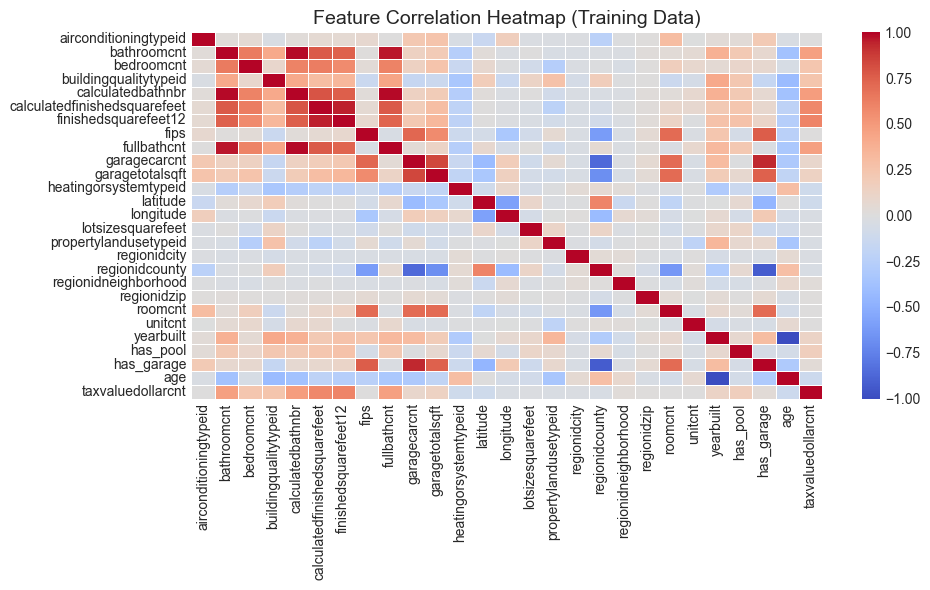


4. Correlation with Target (taxvaluedollarcnt)...
--------------------------------------------------

Top 10 features correlated with target:
finishedsquarefeet12            0.594400
calculatedfinishedsquarefeet    0.579623
calculatedbathnbr               0.477658
fullbathcnt                     0.465740
bathroomcnt                     0.461317
buildingqualitytypeid           0.244221
bedroomcnt                      0.237533
has_pool                        0.171116
garagetotalsqft                 0.135643
yearbuilt                       0.120521

Bottom 5 features (negative correlation):
propertylandusetypeid   -0.037430
regionidcounty          -0.040864
latitude                -0.101800
heatingorsystemtypeid   -0.107953
age                     -0.120521


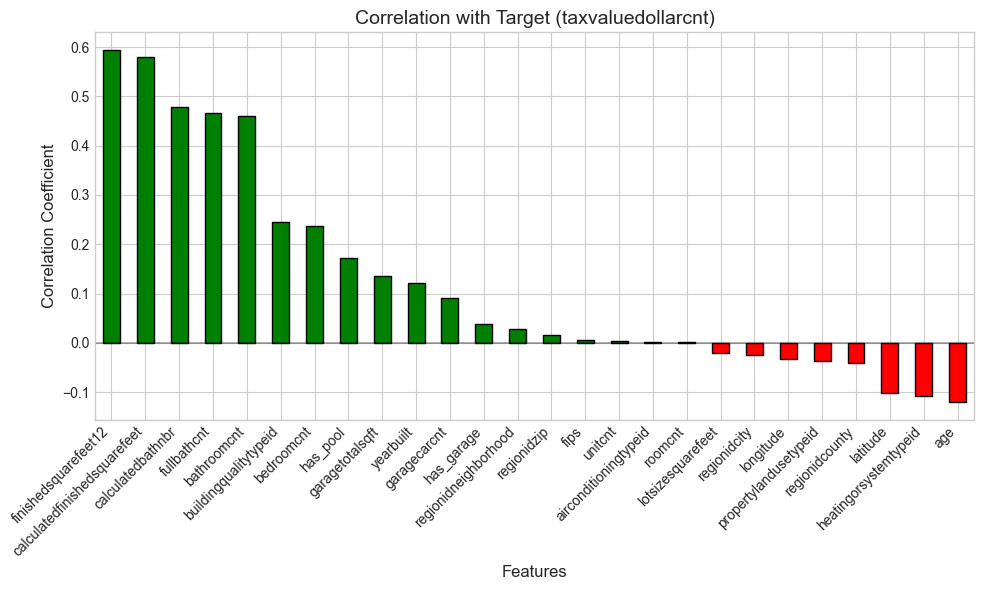


5. Highly Correlated Feature Pairs...
--------------------------------------------------

Top 15 most correlated feature pairs:
    1. age ↔ yearbuilt: 1.000
    2. calculatedbathnbr ↔ fullbathcnt: 0.985
    3. bathroomcnt ↔ calculatedbathnbr: 0.984
    4. bathroomcnt ↔ fullbathcnt: 0.969
    5. calculatedfinishedsquarefeet ↔ finishedsquarefeet12: 0.947
    6. garagecarcnt ↔ has_garage: 0.937
    7. has_garage ↔ regionidcounty: 0.922
    8. garagecarcnt ↔ regionidcounty: 0.860
    9. garagecarcnt ↔ garagetotalsqft: 0.842
   10. calculatedbathnbr ↔ calculatedfinishedsquarefeet: 0.791
   11. calculatedfinishedsquarefeet ↔ fullbathcnt: 0.772
   12. bathroomcnt ↔ calculatedfinishedsquarefeet: 0.767
   13. fips ↔ has_garage: 0.759
   14. calculatedbathnbr ↔ finishedsquarefeet12: 0.756
   15. garagetotalsqft ↔ has_garage: 0.744

6. Computing F-Statistics...
--------------------------------------------------

Top 15 features by F-Statistic:
                     feature  f_statistic       p_v

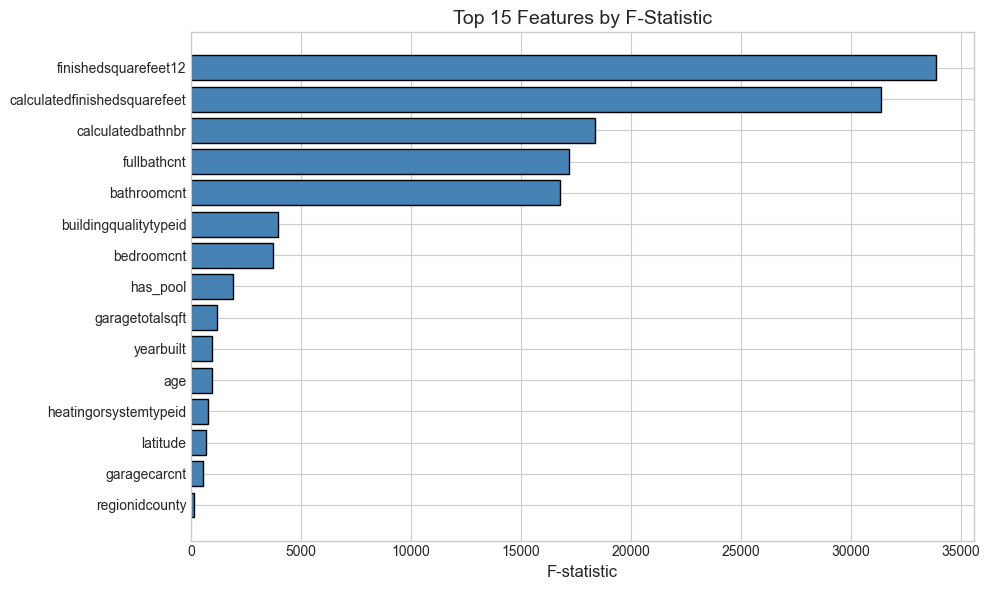


7. Correlation vs F-Statistics Comparison...
--------------------------------------------------

Top 10 features by Correlation vs F-Statistic:
                     Feature  Correlation  F-Statistic
        finishedsquarefeet12     0.594400 33903.048550
calculatedfinishedsquarefeet     0.579623 31396.017407
           calculatedbathnbr     0.477658 18343.453700
                 fullbathcnt     0.465740 17189.136219
                 bathroomcnt     0.461317 16776.386446
       buildingqualitytypeid     0.244221  3935.966798
                  bedroomcnt     0.237533  3710.609058
                    has_pool     0.171116  1871.819882
             garagetotalsqft     0.135643  1163.152212
                   yearbuilt     0.120521   914.651940

4.A DISCUSSION QUESTIONS

1. Which features appear to be the strongest predictors of the target?
   → Check correlation with target (top 5) and F-statistics (top 5)
   → Features with |correlation| > 0.3 are moderately predictive
   → Features with 

In [23]:
# ============================================
# PART 4: Investigate Feature Relationships
# ============================================

print("=" * 70)
print("PART 4: Investigate Feature Relationships")
print("=" * 70)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression

# ============================================
# 4.A: Correlation and Feature Importance
# ============================================

print("\n" + "=" * 60)
print("4.A: Correlation and Feature Importance")
print("=" * 60)

# ------------------------------------------------------------------
# Step 1: Prepare Data (Use Training Data Only!)
# ------------------------------------------------------------------

print("\n1. Preparing Data...")
print("-" * 50)

# Use training data (no missing values!)
X_train_numeric = X_train_imp.select_dtypes(include=[np.number])

# NOTE: taxvaluedollarcnt is NOT in X_train_imp (it's the target)
# So we don't need to drop it!

print(f"✓ Using training data: {X_train_numeric.shape[0]} samples")
print(f"✓ Numeric features: {X_train_numeric.shape[1]}")
print(f"✓ Missing values: {X_train_numeric.isnull().sum().sum()}")

# ------------------------------------------------------------------
# Step 2: Combine X_train_numeric and y_train for correlation
# ------------------------------------------------------------------

print("\n2. Combining features and target for correlation...")
print("-" * 50)

# Combine features and target for correlation calculation
train_with_target = X_train_numeric.copy()
train_with_target['taxvaluedollarcnt'] = y_train

print(f"Combined shape: {train_with_target.shape}")
print(f"Features: {train_with_target.shape[1] - 1}")
print(f"Target: taxvaluedollarcnt")

# ------------------------------------------------------------------
# Step 3: Correlation Matrix
# ------------------------------------------------------------------

print("\n3. Computing Correlation Matrix...")
print("-" * 50)

corr_matrix = train_with_target.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=False
)
plt.title("Feature Correlation Heatmap (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Step 4: Correlation with Target
# ------------------------------------------------------------------

print("\n4. Correlation with Target (taxvaluedollarcnt)...")
print("-" * 50)

# Get correlations with target
target_corr = corr_matrix["taxvaluedollarcnt"].sort_values(ascending=False)
target_corr = target_corr.drop("taxvaluedollarcnt")  # Remove target itself

print("\nTop 10 features correlated with target:")
print(target_corr.head(10).to_string())

print("\nBottom 5 features (negative correlation):")
print(target_corr.tail(5).to_string())

# Visualize
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind="bar", color=colors, edgecolor='black')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title("Correlation with Target (taxvaluedollarcnt)", fontsize=14)
plt.ylabel("Correlation Coefficient", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Step 5: Highly Correlated Feature Pairs
# ------------------------------------------------------------------

print("\n5. Highly Correlated Feature Pairs...")
print("-" * 50)

# Find correlated pairs (excluding target)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
corr_pairs_sorted = corr_pairs.abs().sort_values(ascending=False)

print("\nTop 15 most correlated feature pairs:")
count = 0
for (feat1, feat2), corr in corr_pairs_sorted.items():
    if feat1 != 'taxvaluedollarcnt' and feat2 != 'taxvaluedollarcnt' and count < 15:
        count += 1
        print(f"   {count:2d}. {feat1} ↔ {feat2}: {corr:.3f}")

# ------------------------------------------------------------------
# Step 6: F-Statistics (Feature Importance)
# ------------------------------------------------------------------

print("\n6. Computing F-Statistics...")
print("-" * 50)

# Compute F-statistics (X_train_numeric already has features only)
f_stats, p_values = f_regression(X_train_numeric, y_train)

# Create results DataFrame
f_results = pd.DataFrame({
    "feature": X_train_numeric.columns,
    "f_statistic": f_stats,
    "p_value": p_values
}).sort_values(by="f_statistic", ascending=False)

print("\nTop 15 features by F-Statistic:")
print(f_results.head(15).to_string(index=False))

# Visualize
top = f_results.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["f_statistic"], color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 15 Features by F-Statistic", fontsize=14)
plt.xlabel("F-statistic", fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Step 7: Correlation vs F-Statistics Comparison
# ------------------------------------------------------------------

print("\n7. Correlation vs F-Statistics Comparison...")
print("-" * 50)

# Create comparison
comparison_data = []
for feat in target_corr.index[:10]:
    f_val = f_results[f_results['feature'] == feat]['f_statistic'].values
    comparison_data.append({
        'Feature': feat,
        'Correlation': target_corr[feat],
        'F-Statistic': f_val[0] if len(f_val) > 0 else 0
    })

comparison = pd.DataFrame(comparison_data)
print("\nTop 10 features by Correlation vs F-Statistic:")
print(comparison.to_string(index=False))

# ============================================
# 4.A Discussion Questions
# ============================================

print("\n" + "=" * 60)
print("4.A DISCUSSION QUESTIONS")
print("=" * 60)

print("\n1. Which features appear to be the strongest predictors of the target?")
print("   → Check correlation with target (top 5) and F-statistics (top 5)")
print("   → Features with |correlation| > 0.3 are moderately predictive")
print("   → Features with |correlation| > 0.5 are strongly predictive")

print("\n2. Which pairs of features appear to be highly correlated?")
print("   → Look for pairs with correlation > 0.8")
print("   → These features may be redundant (e.g., multiple bathroom measures)")
print("   → Consider dropping one from each pair in Milestone 2")

print("\n3. Do correlation and F-statistics agree?")
print("   → Compare the top 10 features in both lists")
print("   → If they agree, the relationship is linear")
print("   → If they disagree, there may be non-linear relationships")

print("\n" + "=" * 60)
print("4.A COMPLETE!")
print("=" * 60)

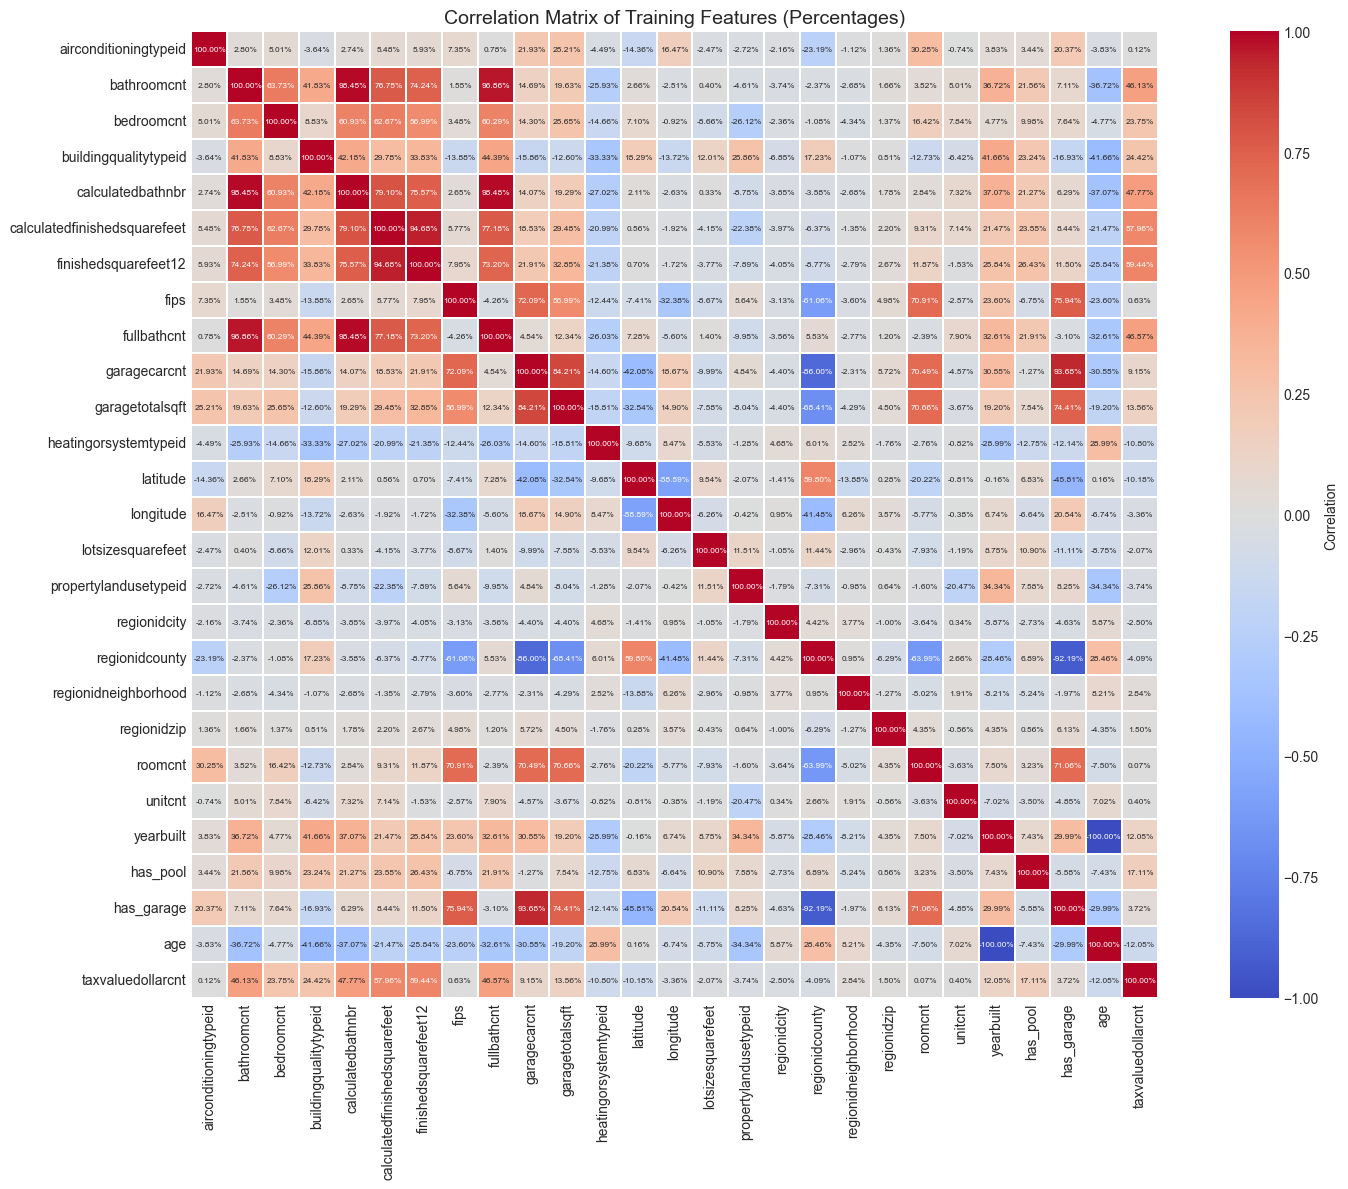

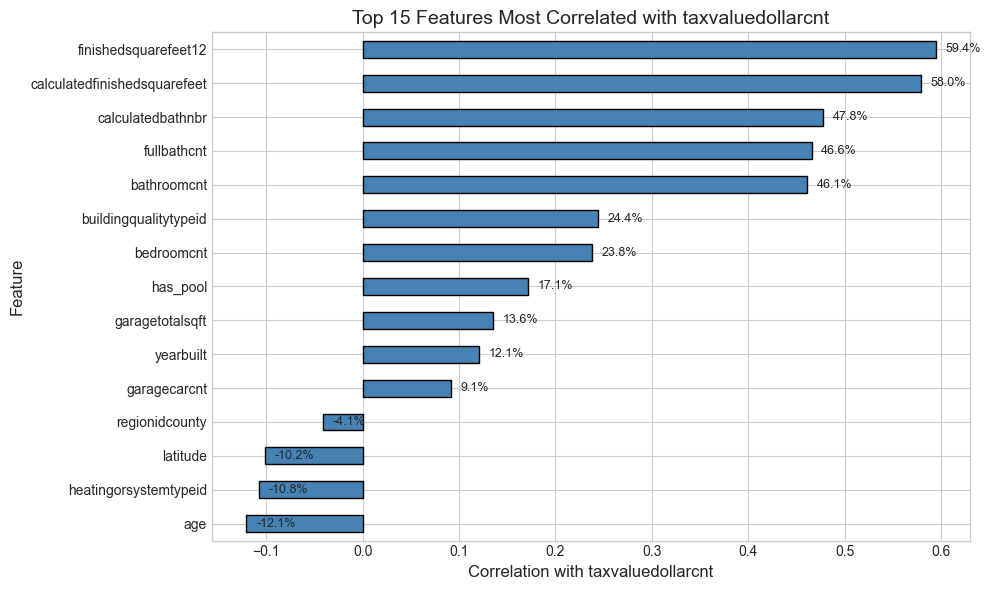


CORRELATION WITH TARGET (taxvaluedollarcnt)
finishedsquarefeet12            0.594400
calculatedfinishedsquarefeet    0.579623
calculatedbathnbr               0.477658
fullbathcnt                     0.465740
bathroomcnt                     0.461317
buildingqualitytypeid           0.244221
bedroomcnt                      0.237533
has_pool                        0.171116
garagetotalsqft                 0.135643
yearbuilt                       0.120521
age                            -0.120521
heatingorsystemtypeid          -0.107953
latitude                       -0.101800
garagecarcnt                    0.091455
regionidcounty                 -0.040864
propertylandusetypeid          -0.037430
has_garage                      0.037176
longitude                      -0.033643
regionidneighborhood            0.028384
regionidcity                   -0.024974
lotsizesquarefeet              -0.020654
regionidzip                     0.014961
fips                            0.006259
unitcnt     

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target
train_df = X_train_imp.copy()
train_df["taxvaluedollarcnt"] = y_train

# Compute correlation matrix
corr_matrix = train_df.corr(numeric_only=True)

# Correlation of each feature with the target
target_corr = (
    corr_matrix["taxvaluedollarcnt"]
    .drop("taxvaluedollarcnt")
    .sort_values(key=abs, ascending=False)
)

# -----------------------------
# Heatmap WITH PERCENTAGE NUMBERS
# -----------------------------
plt.figure(figsize=(16, 12))

# Create heatmap with annotations as percentages
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"},
    annot=True,                     # Show numbers
    fmt='.2%',                      # Format as percentages (e.g., 0.59 → 59%)
    annot_kws={'size': 6}           # Font size for annotations
)

plt.title("Correlation Matrix of Training Features (Percentages)", fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------
# Bar chart of top correlations WITH NUMBERS
# -----------------------------
top_corr = target_corr.head(15)

plt.figure(figsize=(10, 6))
ax = top_corr.sort_values().plot(kind="barh", color="steelblue", edgecolor='black')

# Add correlation values on the bars (as percentages)
for i, (feature, value) in enumerate(top_corr.sort_values().items()):
    ax.text(value + 0.01, i, f'{value:.1%}', va='center', fontsize=9)

plt.xlabel("Correlation with taxvaluedollarcnt", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 15 Features Most Correlated with taxvaluedollarcnt", fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------
# Print correlation numbers
# -----------------------------
print("\n" + "=" * 60)
print("CORRELATION WITH TARGET (taxvaluedollarcnt)")
print("=" * 60)
print(target_corr.to_string())

# -----------------------------
# Optional: Print as percentages
# -----------------------------
print("\n" + "=" * 60)
print("CORRELATION WITH TARGET (as percentages)")
print("=" * 60)
for feature, corr in target_corr.items():
    print(f"   {feature}: {corr:.1%}")

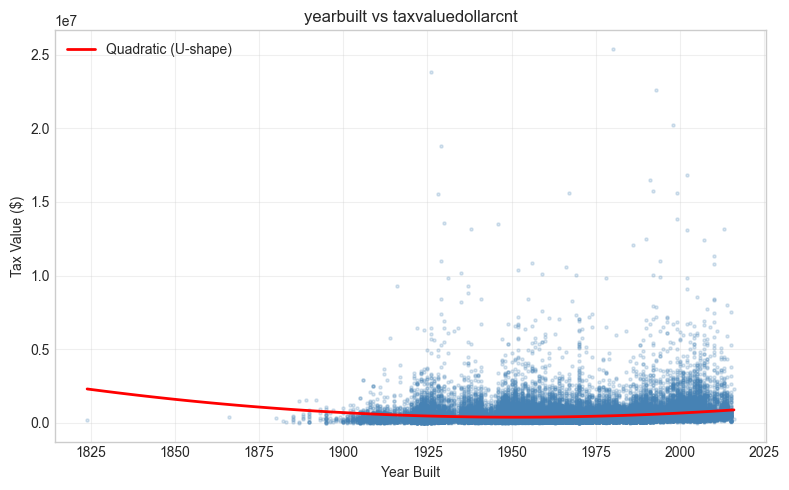

In [36]:
plt.figure(figsize=(8, 5))

# Scatter
plt.scatter(X_train_imp['yearbuilt'], y_train, alpha=0.2, s=5, color='steelblue')

# Fits
x = X_train_imp['yearbuilt'].values
y = y_train.values
x_smooth = np.linspace(min(x), max(x), 100)

# Quadratic (U-shape)
quad_func = np.poly1d(np.polyfit(x, y, 2))
plt.plot(x_smooth, quad_func(x_smooth), 'red', linewidth=2, label='Quadratic (U-shape)')

plt.xlabel('Year Built')
plt.ylabel('Tax Value ($)')
plt.title('yearbuilt vs taxvaluedollarcnt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> Replace this text with your answer.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> Replace this text with your answer.

#### **5 Discussion:** 

Describe in a paragraph why you chose these transformations and what you observed. 


To be deleted!

Dustin worked on Part 1, 2, 3. Larry worked on part 4, Jegan part 5
See the completed notebook: Copy of submitted OMDS_Mod3_Milestone_01_LC-DN-JA.ipynb

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

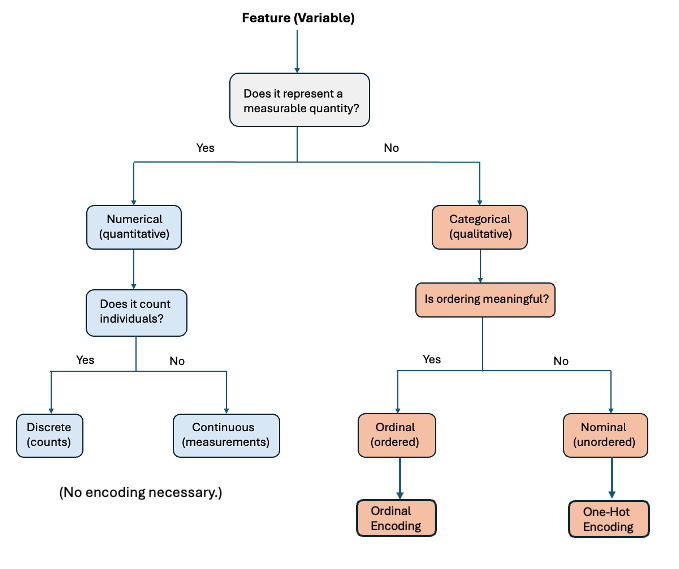